# Vehicle Scheduling from Trip Data

Welcome to this notebook! 🚍🪡

This notebook demonstrates how to transform a set of trips into executable driving missions for a fleet of vehicles.

We start with a list of trips, where each trip typically represents a journey between two end stations (e.g., from one terminal stop to another in a public bus network). These trips form the fundamental building blocks of daily operations, but on their own they do not specify how vehicles should be assigned or sequenced.

The goal of this notebook is to show how these individual trips can be allocated to vehicles. By chaining compatible trips together—based on timing, and location, we construct coherent driving missions. Each mission represents the sequence of trips that a single vehicle will perform.

- **Input:** A list of vehicles.
- **Output:** A list of driving missions.

In the following sections, we will:

* Define a list of trips.
* Create driving missions using `trip-stitcher`.
* Visualize the result.

Let's start! 🚀

# Loading Data

The first step in this notebook is to load the transport data from a **Parquet file**. 

This file contains all the essential information needed for route finding, including:

- **Routes:** The different public transport lines available.  
- **Trips:** Individual scheduled trips for each route.  
- **Stops:** Geographic locations of each stop on the routes.  

Let's load the data and take a quick look at its structure.

In [3]:
from pathlib import Path

import pandas as pd

root = Path("..")

parquet_path = Path(root / "data/postauto.parquet")
df = pd.read_parquet(parquet_path)
print(f"DataFrame contains {len(df)} rows")
df.head()

DataFrame contains 2650955 rows


,agency_id,route_id,route_short_name,trip_id,service_id,monday,start_date,end_date,stop_sequence,arrival_time,departure_time,stop_id,stop_name,stop_lat,stop_lon
0,801,96-100-0-j25-1,220,1.TA.96-100-0-j25-1.8.H,TA+2e000#1,1,20241215,20251213,1,07:27:00,07:27:00,8571330,"Reichenbach i. K., Bahnhof",46.625525,7.690208
1,801,96-100-0-j25-1,220,1.TA.96-100-0-j25-1.8.H,TA+2e000#1,1,20241215,20251213,2,07:28:00,07:28:00,8571331,"Reichenbach i. K., Bären",46.625432,7.694187
2,801,96-100-0-j25-1,220,1.TA.96-100-0-j25-1.8.H,TA+2e000#1,1,20241215,20251213,3,07:30:00,07:30:00,8583254,"Scharnachtal, Halten",46.620608,7.697223
3,801,96-100-0-j25-1,220,1.TA.96-100-0-j25-1.8.H,TA+2e000#1,1,20241215,20251213,4,07:32:00,07:32:00,8507766,"Scharnachtal, Viesen",46.617979,7.697807
4,801,96-100-0-j25-1,220,1.TA.96-100-0-j25-1.8.H,TA+2e000#1,1,20241215,20251213,5,07:33:00,07:33:00,8571332,"Scharnachtal, Schulhaus",46.614709,7.698158


# Generating Trips from Routes

We start by creating the initial list of trips that will later be allocated to vehicles. We use the `RouteLocator` and `RadiusQuery` classes to make our selection.

In [4]:
from loguru import logger

logger.remove()  # prevent ocsept from logging

from trip_stitcher.models import RadiusQuery, Route, Stop, Trip
from trip_stitcher.route_locator import RouteLocator

radius_query = RadiusQuery(lat=47.03994, lon=9.07124, radius=500)

trip_dict = dict(
    (trip.id, trip) for trip in Trip.list_from_dataframe(df)
)  # Trip dictionary for trip lookup
stop_dict = dict(
    (stop.id, stop) for stop in Stop.list_from_dataframe(df)
)  # Stop dictionary for stop lookup
route_dict = dict(
    (route.id, route) for route in Route.list_from_dataframe(df)
)  # Route dictionary for route lookup
route_locator = RouteLocator(
    Route.list_from_dataframe(df), Trip.list_from_dataframe(df), Stop.list_from_dataframe(df)
)

routes = route_locator.radius_query(radius_query)
print(f"Found {len(routes)} Routes:")
for i, route in enumerate(routes):
    print(f"  {i + 1}. {route.name} ({route.id})")

trips = []
for route in routes:
    trips += [trip_dict[trip_id] for trip_id in route.trips]
print(f"Found {len(trips)} trips")

Found 8 Routes:
  1. 502 (96-241-8-j26-1)
  2. 502 (96-241-8-j25-1)
  3. 501 (96-241-7-j26-1)
  4. 501 (96-241-7-j25-1)
  5. 503 (96-241-5-j26-1)
  6. 503 (96-241-5-j25-1)
  7. 536 (96-243-6-j25-1)
  8. 504 (96-241-6-j25-1)
Found 451 trips


# Creating Driving Missions

Once we have imported the necessary functionality from `trip_stitcher.stitching`, we can generate driving missions from our list of trips with just a single line of code.

A driving mission is a sequence of trips assigned to a single vehicle. The rules for adding a trip to an existing driving mission are simple:

- A trip can be appended to a driving mission if the mission currently ends at the same stop where the trip starts, and
the mission ends before the trip’s start time.
- Since we are adding a `route_dict` to `build_default_is_addable`, vehicle types also need to match.
- There is also the option to supply `max_capacity` as an argument, which is not used in this notebook, since we ignore energy demands altogether.

This ensures that trips are only chained together when a vehicle can feasibly move from one trip to the next, respecting both location and timing constraints.

In [5]:
from trip_stitcher.stitching import build_default_is_addable, stitch_trips_into_driving_missions

is_addable = build_default_is_addable(route_dict=route_dict)


driving_missions = stitch_trips_into_driving_missions(trips, is_addable)
print(f"Distributed {len(trips)} trips to {len(driving_missions)} driving missions")

Distributed 451 trips to 38 driving missions


# Visualizing Driving Missions

In this final step, we visualize the generated driving missions to better understand how vehicles are utilized over time.

The resulting plot illustrates how vehicles move between terminal stations throughout the schedule:

- The x-axis represents time
- The y-axis represents terminal stations
- Each colored line corresponds to a single driving mission (i.e., one vehicle’s sequence of trips)

This visualization makes it easy to see how trips are chained together, and how vehicles transition between stations.

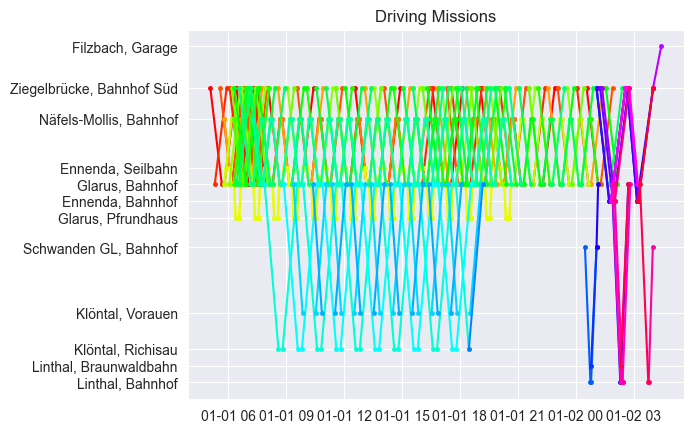

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

from trip_stitcher.plot_utils import color_map, name_to_line_map
from trip_stitcher.utils import str_to_datetime

terminal_stops = []
for trip in trips:
    terminal_stops.append(stop_dict[trip.stops[0]])
    terminal_stops.append(stop_dict[trip.stops[-1]])

line_map = name_to_line_map(terminal_stops)

sns.set_style("darkgrid")
colors = [color_map(i / len(driving_missions)) for i in range(len(driving_missions))]
for color, driving_mission in zip(colors, driving_missions):
    for trip in driving_mission.trips:
        trip_start_time = str_to_datetime(trip.arrival_times[0])
        trip_end_time = str_to_datetime(trip.arrival_times[-1])
        start = line_map[stop_dict[trip.stops[0]].name]
        stop = line_map[stop_dict[trip.stops[-1]].name]
        plt.plot([trip_start_time, trip_end_time], [start, stop], c=color, marker=".", markersize=5)
plt.yticks(list(line_map.values()), list(line_map.keys()))
plt.title("Driving Missions")
plt.show()